## CMPINF 2100 Week 06
### Categorical to continuous variale relationships
### OR Conditional Distributions

A Brief Note on Categorical-to-Continuous Relationships
It is critically important to study the relationship between categorical and continuous variables. There are multiple plot types we can use, but we should ask ourselves the GOAL or QUESTION we are focused on BEFORE making the plot. The video below shows how to answer three related yet DIFFERENT QUESTIONS about the relationship between categorical and continuous variables. You will first learn how to visually study if the DISTRIBUTION changes across categories using faceted histograms and CONDITIONAL KDE plots. Common pitfalls addressed with the default Seaborn operation of such figures are addressed. Next, the video shows how to use BOXPLOTS to address if summary statistics of the continuous variable change across categories. Lastly, the POINT PLOT is introduced to examine if the AVERAGE changes across the categories. The POINT PLOT includes the STANDARD ERROR via the CONFIDENCE INTERVAL and thus you can address if you are confident that the average is different!

We have previoulsy examined the counts of categorical variables by themselves. The distribution of continuous vaiables by themselves. Let's now consider how a continuous variable's distribution changes across the categories of a categorical variable. Meaning, the distribution is CONDITIONED on or GROUPED BY a categorical variable

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## Read Data

In [3]:
penguins = sns.load_dataset('penguins')

In [4]:
gap_url = 'https://raw.githubusercontent.com/chendaniely/pandas_for_everyone/master/data/gapminder.tsv'

In [5]:
gap_df = pd.read_csv(gap_url, sep = '\t')

In [6]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [7]:
gap_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 80.0+ KB


## Penguins
We previously looked at the MARGINAL distribution of flipper_length_mm

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


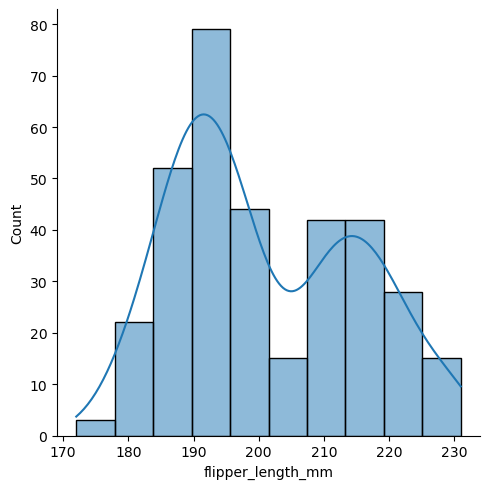

In [8]:
sns.displot( data = penguins, x='flipper_length_mm', kind='hist', kde=True)
plt.show()

But...let's now CONDITION or GROUP BY the categorical variable 'species'! We will therefore examine if the distributin of 'flipper_length_mm' changes or is different across the categories of 'species'"

One way to create this figure is as a histogram that is colored by species


/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


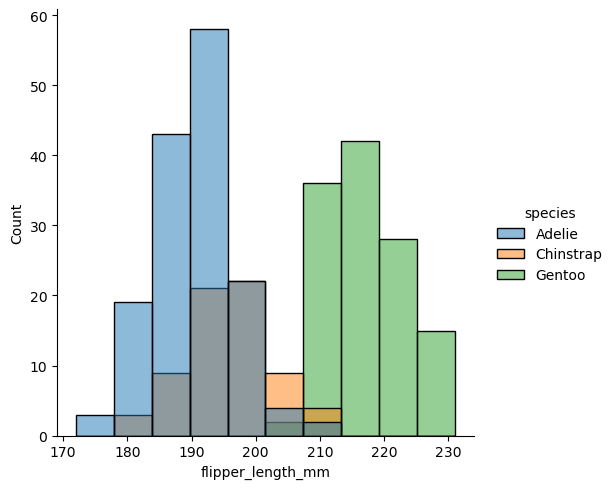

In [9]:
sns.displot(data = penguins, x='flipper_length_mm', hue='species', kind='hist')
plt.show()

DO NOT USE HISTOGRAM WITH COLORS

You should use FACETS to represent the categories of a secon categorical variable when showing the distribution as a histogram.

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


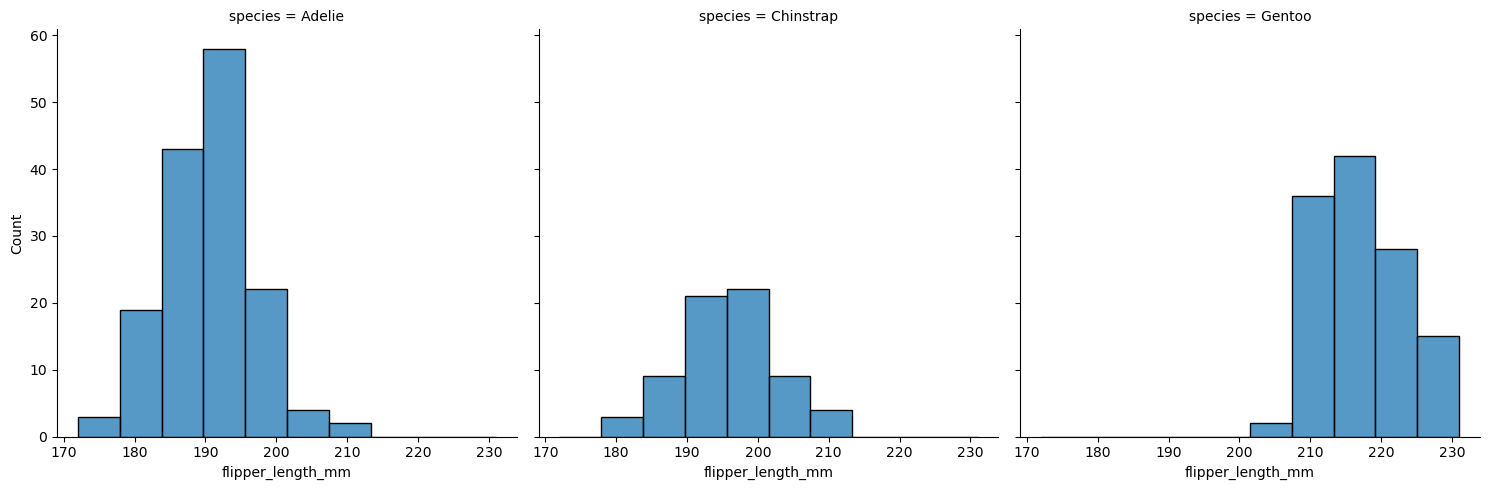

In [10]:
sns.displot(data = penguins, x='flipper_length_mm', col='species', kind='hist')
plt.show()

In [11]:
penguins.species.value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

We cannot use the bar height of the historgram alone. We need to change how we represent concentration

It is better to use the DENSITY to visualize concentration rather than count

We will use the KDE plot or relay on the GROUPED or CONDITIONAL KDE plot to study how the distribution varies across categories

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


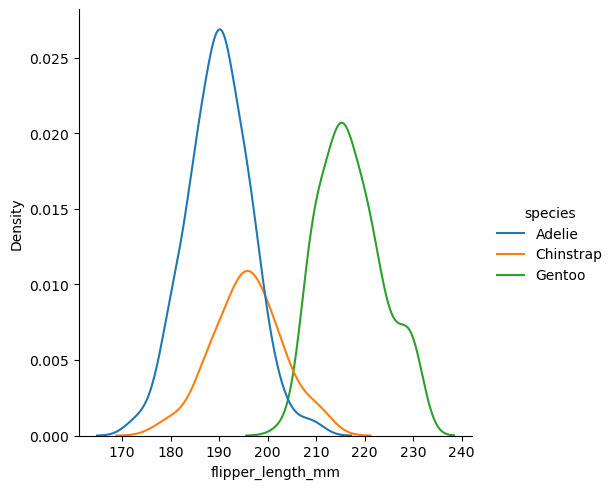

In [13]:
sns.displot( data = penguins, x = 'flipper_length_mm', hue='species', kind='kde' )
plt.show()

Unfotunately...Seaborn does not handle the SAMPLE SIZE Correctly with grouped or conditional KDE Plots!!

Seaborn is getting fooled by sample size

We need to remove the sample size effect

To do that we must include the common_norm=False argument

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


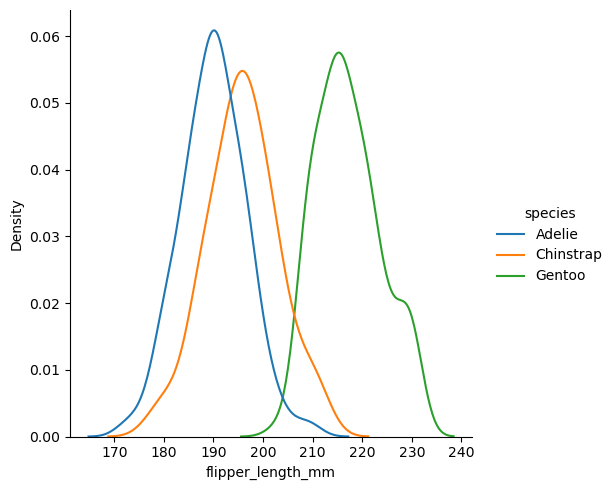

In [14]:
sns.displot(data = penguins, x='flipper_length_mm', hue='species',
            common_norm=False, kind='kde')
plt.show()

Sometimes we just want to know useful SUMMARY statistics

E.g. is the MEDIAN changing across the categories

What is the median? 50% of the observations are LESS than the MEDIAN. 50% of the observations are greater in vlaue than the Median

In [16]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [17]:
penguins.flipper_length_mm.median()

197.0

In [18]:
penguins.loc[penguins.flipper_length_mm < penguins.flipper_length_mm.median(), :].shape[0]

166

In [20]:
penguins.loc[penguins.flipper_length_mm < penguins.flipper_length_mm.median(), :].shape[0] / penguins.shape[0]

0.48255813953488375

In [21]:
penguins.loc[penguins.flipper_length_mm <= penguins.flipper_length_mm.median(), :].shape[0] / penguins.shape[0]

0.5116279069767442

We can easily visualize how the median changes across categories via a Box plot

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


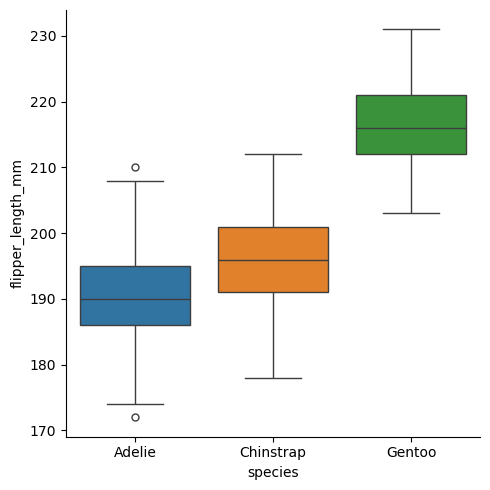

In [25]:
sns.catplot( data = penguins, x='species', y='flipper_length_mm', kind='box', hue='species')
plt.show()

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


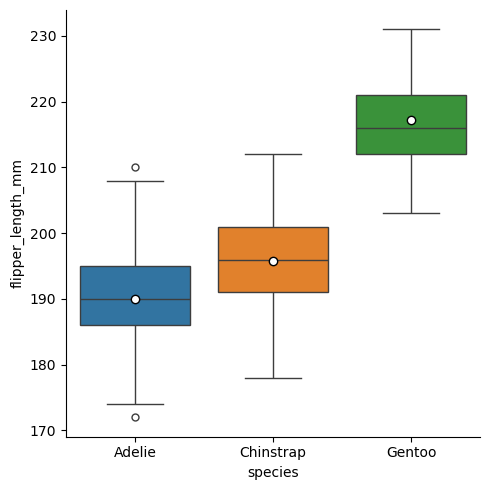

In [27]:
sns.catplot(data = penguins, x='species', y='flipper_length_mm', kind='box', hue='species',
            showmeans=True,
           meanprops={'marker': 'o', 'markerfacecolor':'white', 'markeredgecolor':'black'})
plt.show()

Seaborn allows us to visually identify if we can TRUST if the average is different across groups!

Seaborn can include the CONFIDENCE INTERVAL or the STANDARD ERROR INTERVAL around the average!

The confidence interval interval can be included via the POINT PLOT!!

## Point Plot
Point Plot is focused on comparing averages across groups!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


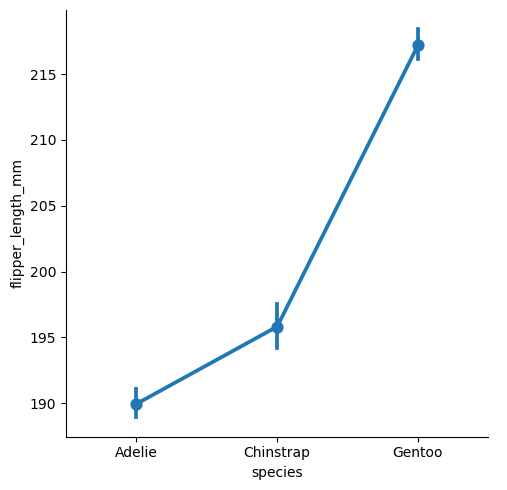

In [28]:
sns.catplot( data = penguins, x='species', y='flipper_length_mm', kind='point')
plt.show()

/var/folders/w2/67mk25c54mj4_5lpd9wgfrxm0000gq/T/ipykernel_23904/1742785426.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot( data = penguins, x='species', y='flipper_length_mm', kind='point', join=False)
/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


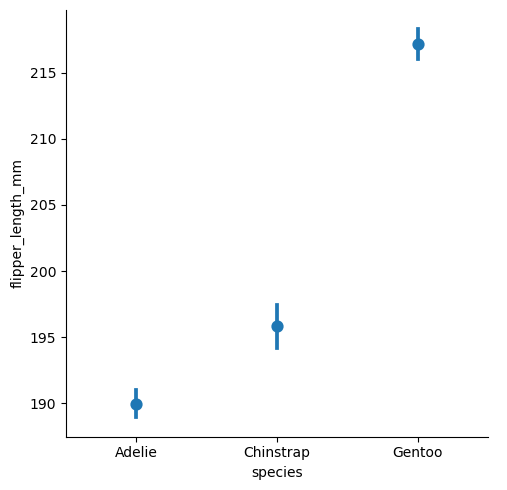

In [30]:
sns.catplot( data = penguins, x='species', y='flipper_length_mm', kind='point', join=False)
plt.show()

## Gap Minder

The 'year' variable has just 12 unique values. Let's continue to treat it as a categrical for our visual exploration.

Let's examine if the year is associated with changes in the lifeExp variable

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


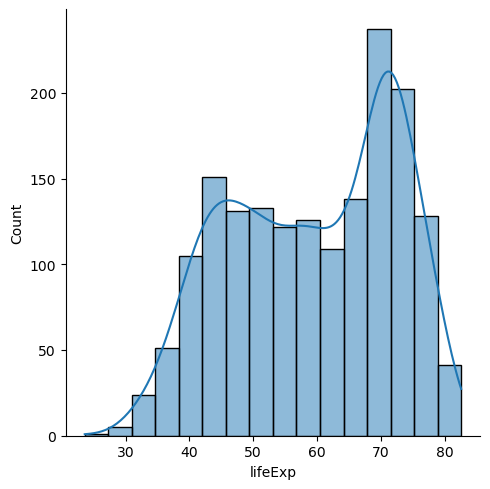

In [32]:
sns.displot( data = gap_df, x='lifeExp', kind='hist', kde=True )
plt.show()

the conditional KDE given or GROUPED BY year

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


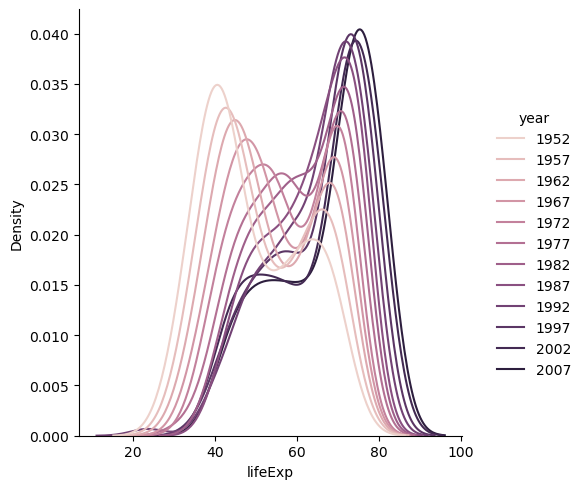

In [33]:
sns.displot(data = gap_df, x='lifeExp', hue='year', kind='kde', common_norm=False)
plt.show()

Let's streamline things and focus on the summary statistics for now, rather than on the distributional shape

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


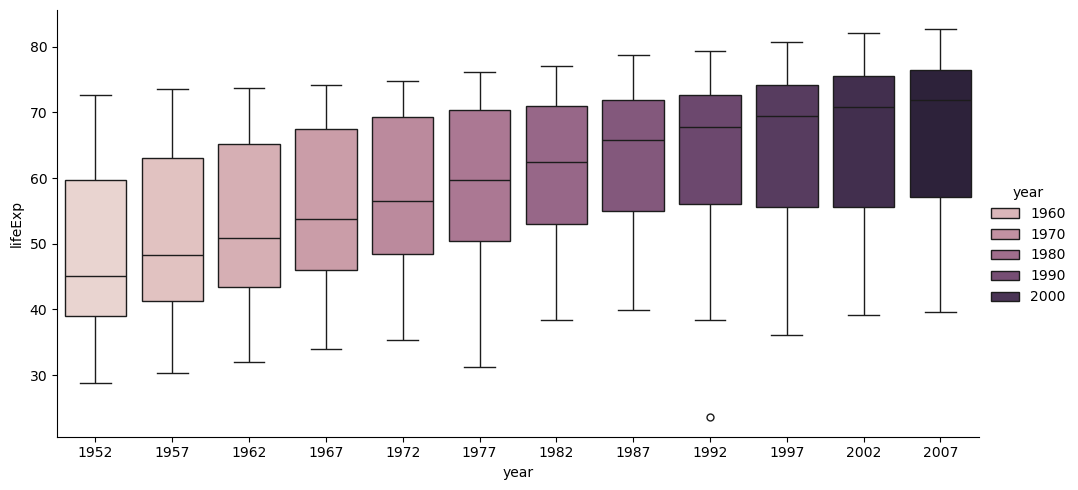

In [41]:
sns.catplot( data = gap_df, x='year', y='lifeExp', kind='box', hue='year', aspect=2)
plt.show()

Is the average lifeExp changing...I need to examine the POINT PLOT!!!

/var/folders/w2/67mk25c54mj4_5lpd9wgfrxm0000gq/T/ipykernel_23904/877293189.py:1: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.catplot( data = gap_df, x='year', y='lifeExp', kind='point', aspect=2, join=False)
/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


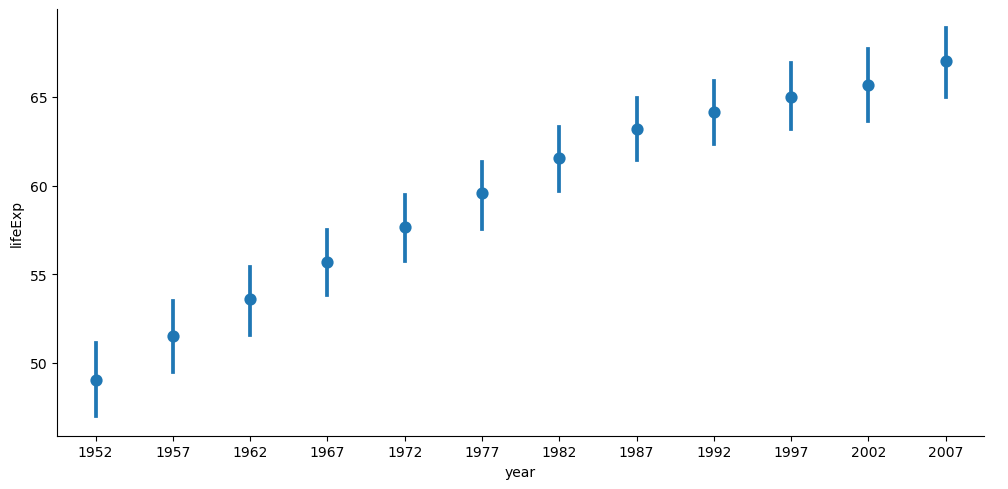

In [44]:
sns.catplot( data = gap_df, x='year', y='lifeExp', kind='point', aspect=2, join=False)
plt.show()


We can COLOR by a 3rd variable or a SECONDARY categorical variable in a boxplot...

Let's examine the distribution of the lifeExp per 'year' per 'continent'

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


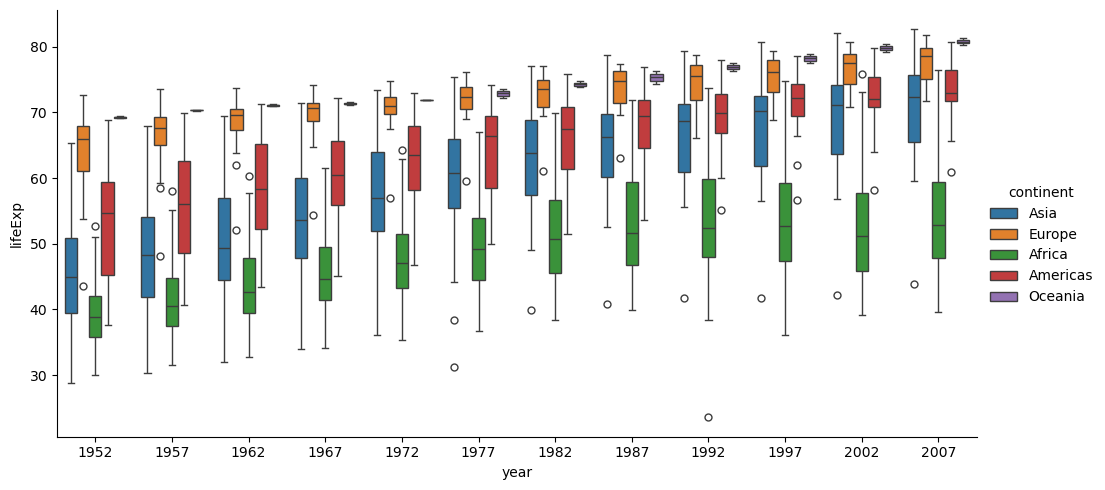

In [45]:
sns.catplot( data = gap_df, x='year', y='lifeExp', hue='continent', kind='box', aspect=2)
plt.show()